# Statevector Benchmark Comparison

This notebook compares correctness and runtime of four methods on the same random circuit:
- einsum simulator (`CustomSimulatorGeneral`)
- Qiskit Aer statevector reference (`AerSimulator` with `fusion_enable=False`, `max_parallel_threads=1`)
- optimized simulator (python backend)
- optimized simulator (numba backend)

The timing uses `time.perf_counter`, and statevectors are compared up to global phase.

In [7]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from qiskit import transpile
from qiskit.circuit.random import random_circuit
from qiskit_aer import AerSimulator

from fp_qsim.simulator import CustomSimulatorGeneral
from fp_qsim.simulator_optimized import CustomSimulatorManualOptimized

In [8]:
def align_global_phase(reference: np.ndarray, candidate: np.ndarray) -> np.ndarray:
    """Align candidate to reference by matching the phase of the strongest amplitude."""
    anchor = int(np.argmax(np.abs(reference)))
    if np.isclose(candidate[anchor], 0.0):
        return candidate
    return candidate * (reference[anchor] / candidate[anchor])


def make_random_ucx_circuit(n_qubits: int, depth: int, seed: int):
    """Create a random circuit and transpile it to the ['u', 'cx'] basis."""
    qc = random_circuit(n_qubits, depth, measure=False, seed=seed)
    return transpile(qc, basis_gates=["u", "cx"])


def benchmark_method(method_name: str, runner, circuit, repeats: int = 3) -> dict:
    """Time one method over multiple repeats and return runtime stats plus last output."""
    timings = []
    output = None

    for _ in range(repeats):
        start = perf_counter()
        output = runner(circuit)
        end = perf_counter()
        timings.append(end - start)

    return {
        "method": method_name,
        "mean_s": float(np.mean(timings)),
        "min_s": float(np.min(timings)),
        "max_s": float(np.max(timings)),
        "repeats": repeats,
        "statevector": output,
    }


def compare_statevectors(reference: np.ndarray, candidate: np.ndarray, atol: float = 1e-10):
    """Compare candidate with reference up to global phase."""
    aligned = align_global_phase(reference, candidate)
    max_abs_error = float(np.max(np.abs(reference - aligned)))
    return bool(np.allclose(reference, aligned, atol=atol)), max_abs_error

In [9]:
def run_comparison(n_qubits: int = 6, depth: int = 20, seed: int = 42, repeats: int = 3) -> dict:
    """Run correctness and runtime comparison for one random circuit."""
    circuit = make_random_ucx_circuit(n_qubits=n_qubits, depth=depth, seed=seed)

    sim_einsum = CustomSimulatorGeneral()
    sim_opt_python = CustomSimulatorManualOptimized(cx_backend="python")
    sim_opt_numba = CustomSimulatorManualOptimized(cx_backend="numba")

    aer_statevector_backend = AerSimulator(
        method="statevector",
        fusion_enable=False,
        max_parallel_threads=1,
    )

    def qiskit_aer_statevector(qc):
        qc_aer = qc.copy()
        qc_aer.save_statevector()
        compiled = transpile(qc_aer, aer_statevector_backend)
        result = aer_statevector_backend.run(compiled).result()
        return np.asarray(result.get_statevector(compiled), dtype=complex)

    methods = [
        ("einsum", lambda qc: sim_einsum.run(qc)),
        ("qiskit_aer", lambda qc: qiskit_aer_statevector(qc)),
        ("optimized_python", lambda qc: sim_opt_python.run(qc)),
        ("optimized_numba", lambda qc: sim_opt_numba.run(qc)),
    ]

    results = {}
    for method_name, runner in methods:
        results[method_name] = benchmark_method(method_name, runner, circuit, repeats=repeats)

    reference = results["qiskit_aer"]["statevector"]
    comparisons = {}

    for method_name, data in results.items():
        is_close, max_abs_error = compare_statevectors(reference, data["statevector"])
        comparisons[method_name] = {
            "matches_reference": is_close,
            "max_abs_error": max_abs_error,
        }

    header = f"\nComparison for n_qubits={n_qubits}, depth={depth}, seed={seed}, repeats={repeats}"
    print(header)
    print("-" * len(header))
    print(f"{'Method':<20} {'Mean [ms]':>12} {'Min [ms]':>12} {'Max [ms]':>12} {'Match ref':>10} {'Max |err|':>14}")

    for method_name in ["einsum", "qiskit_aer", "optimized_python", "optimized_numba"]:
        timing = results[method_name]
        cmp_data = comparisons[method_name]
        print(
            f"{method_name:<20} "
            f"{timing['mean_s'] * 1_000:>12.3f} "
            f"{timing['min_s'] * 1_000:>12.3f} "
            f"{timing['max_s'] * 1_000:>12.3f} "
            f"{str(cmp_data['matches_reference']):>10} "
            f"{cmp_data['max_abs_error']:>14.3e}"
        )

    return {
        "config": {"n_qubits": n_qubits, "depth": depth, "seed": seed, "repeats": repeats},
        "results": results,
        "comparisons": comparisons,
        "circuit": circuit,
    }

In [10]:
# Single benchmark run
single_result = run_comparison(n_qubits=6, depth=20, seed=42, repeats=3)


Comparison for n_qubits=6, depth=20, seed=42, repeats=3
--------------------------------------------------------
Method                  Mean [ms]     Min [ms]     Max [ms]  Match ref      Max |err|
einsum                      3.583        3.262        4.130       True      3.354e-16
qiskit_aer                 47.550       31.443       76.469       True      6.939e-18
optimized_python            2.964        2.925        2.998       True      3.410e-16
optimized_numba             0.737        0.678        0.841       True      4.034e-16


In [ ]:
# Small qubit-count sweep
sweep_results = {}
for n in [4,5,6,7,8,9,10,   11,12,13,14,15,16]:
    sweep_results[n] = run_comparison(n_qubits=n, depth=3 * n, seed=42 + n, repeats=2)

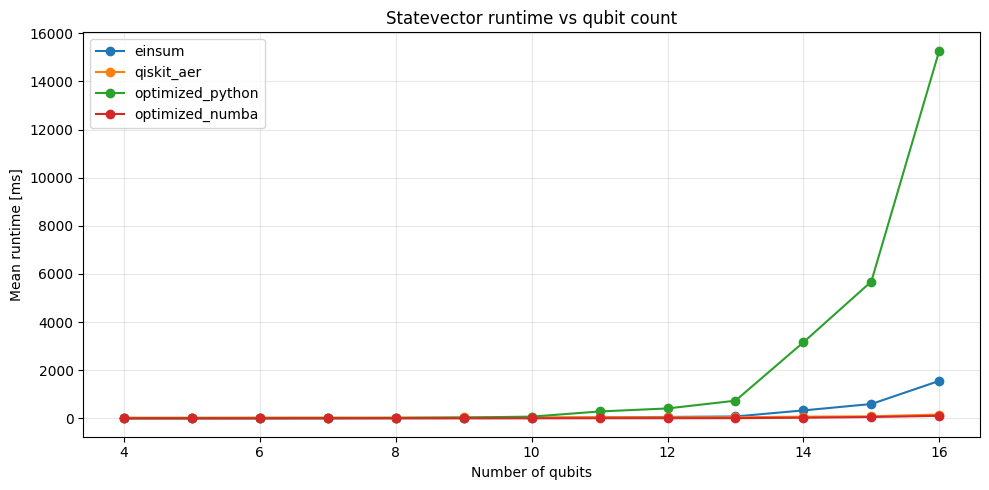

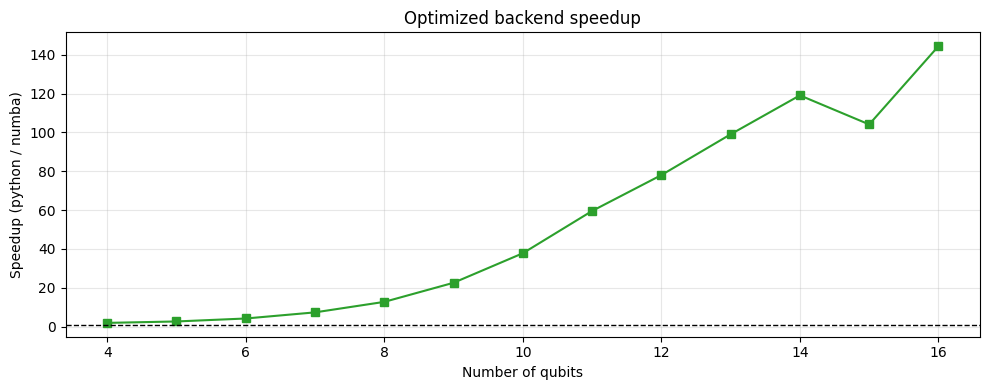

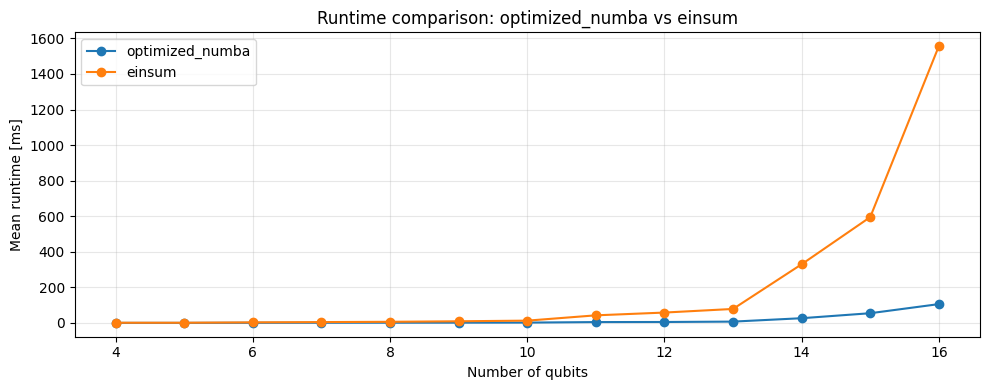

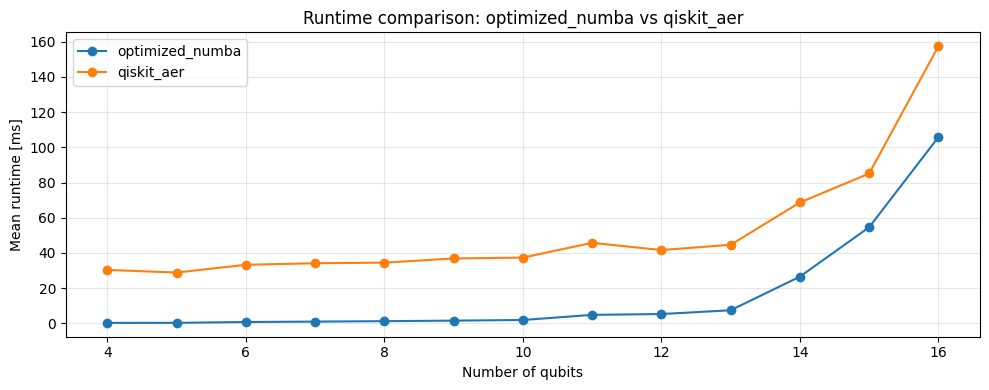

In [12]:
# Plot helper for sweep results
def plot_sweep_results(sweep_results: dict) -> None:
    qubits = sorted(sweep_results.keys())
    methods = ["einsum", "qiskit_aer", "optimized_python", "optimized_numba"]

    # Collect mean runtime in milliseconds for each method
    runtime_ms = {method: [] for method in methods}
    for n in qubits:
        for method in methods:
            runtime_ms[method].append(sweep_results[n]["results"][method]["mean_s"] * 1_000.0)

    plt.figure(figsize=(10, 5))
    for method in methods:
        plt.plot(qubits, runtime_ms[method], marker="o", label=method)
    plt.xlabel("Number of qubits")
    plt.ylabel("Mean runtime [ms]")
    plt.title("Statevector runtime vs qubit count")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Speedup of optimized_numba compared to optimized_python
    speedup = [
        runtime_ms["optimized_python"][i] / runtime_ms["optimized_numba"][i]
        for i in range(len(qubits))
    ]

    plt.figure(figsize=(10, 4))
    plt.plot(qubits, speedup, marker="s", color="tab:green")
    plt.axhline(1.0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Number of qubits")
    plt.ylabel("Speedup (python / numba)")
    plt.title("Optimized backend speedup")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Direct runtime comparison: optimized_numba vs einsum
    plt.figure(figsize=(10, 4))
    plt.plot(qubits, runtime_ms["optimized_numba"], marker="o", label="optimized_numba")
    plt.plot(qubits, runtime_ms["einsum"], marker="o", label="einsum")
    plt.xlabel("Number of qubits")
    plt.ylabel("Mean runtime [ms]")
    plt.title("Runtime comparison: optimized_numba vs einsum")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Direct runtime comparison: optimized_numba vs qiskit_aer
    plt.figure(figsize=(10, 4))
    plt.plot(qubits, runtime_ms["optimized_numba"], marker="o", label="optimized_numba")
    plt.plot(qubits, runtime_ms["qiskit_aer"], marker="o", label="qiskit_aer")
    plt.xlabel("Number of qubits")
    plt.ylabel("Mean runtime [ms]")
    plt.title("Runtime comparison: optimized_numba vs qiskit_aer")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_sweep_results(sweep_results)


Speedup summary (baseline / optimized_numba)
--------------------------------------------------------------
Qubits   Baseline                Speedup
12       einsum                   11.053x
12       qiskit_aer                7.890x
12       optimized_python         78.020x
16       einsum                   14.705x
16       qiskit_aer                1.488x
16       optimized_python        144.359x


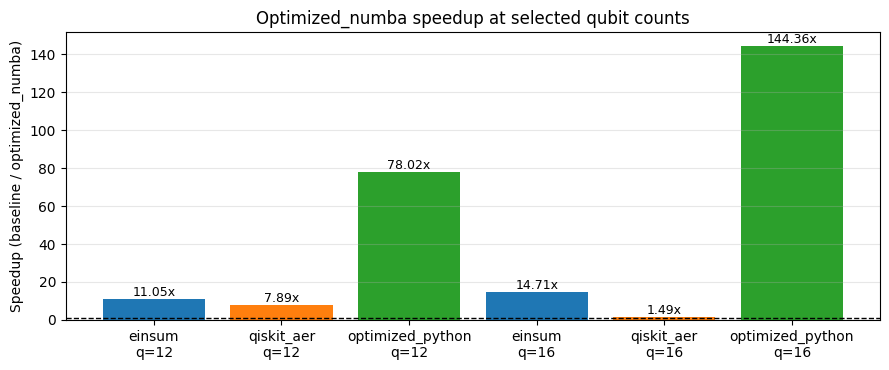

In [14]:
# Speedup summary: optimized_numba compared to all other methods at 12 and 16 qubits
def print_numba_speedup_summary(sweep_results: dict, qubit_points=(12, 16)) -> None:
    baselines = ["einsum", "qiskit_aer", "optimized_python"]
    print("\nSpeedup summary (baseline / optimized_numba)")
    print("-" * 62)
    print(f"{'Qubits':<8} {'Baseline':<18} {'Speedup':>12}")

    labels = []
    speedup_values = []

    for n in qubit_points:
        if n not in sweep_results:
            print(f"{n:<8} {'missing':<18} {'n/a':>12}")
            continue

        numba_ms = sweep_results[n]["results"]["optimized_numba"]["mean_s"] * 1_000.0
        for baseline in baselines:
            baseline_ms = sweep_results[n]["results"][baseline]["mean_s"] * 1_000.0
            speedup = baseline_ms / numba_ms if numba_ms > 0 else float("inf")
            print(f"{n:<8} {baseline:<18} {speedup:>12.3f}x")
            labels.append(f"{baseline}\nq={n}")
            speedup_values.append(speedup)

    if not speedup_values:
        return

    # Compact bar chart for speedup at selected qubit points.
    plt.figure(figsize=(9, 3.8))
    bars = plt.bar(labels, speedup_values, color=["#1f77b4", "#ff7f0e", "#2ca02c"] * len(qubit_points))
    plt.axhline(1.0, color="black", linestyle="--", linewidth=1)
    plt.ylabel("Speedup (baseline / optimized_numba)")
    plt.title("Optimized_numba speedup at selected qubit counts")
    plt.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, speedup_values):
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height(),
            f"{val:.2f}x",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


print_numba_speedup_summary(sweep_results)